PHASE 1

In [2]:
import pandas as pd
import glob
import os
# combine all payment(BOLT) csv files into one file and creating a dataframe
files= glob.glob(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\bolt_payment\*.csv')
df_bolt_payments_raw = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df_bolt_payments_raw.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\bolt_payment\bolt_payment_stacked.csv', index=False)



In [3]:
# combine all ride(BOLT) csv files into one file and creating a dataframe 
path= r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\Order history\order_history'
files = glob.glob(path + "/**/*.csv", recursive=True)
df_bolt_trips_raw = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
df_bolt_trips_raw.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\BOLT\Order history\order_history_stacked.csv', index=False)

In [4]:
# read the Uber trips csv file and creating a dataframe
path = r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\Uber\uber_trips.csv'
df_uber_trips_raw= pd.read_csv(path)

# read the Uber payments csv file and creating a dataframe
path = r"C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\Uber\uber_payments.csv"
df_uber_payments_raw= pd.read_csv(path)


In [5]:
import pyodbc
import pandas as pd

from sqlalchemy import create_engine

conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=LAMOSKI;"
    "Database=RideMetrics;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)
engine = create_engine("mssql+pyodbc://LAMOSKI/RideMetrics?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&encrypt=no")


cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")
print(cursor.fetchone())

('Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) \n\tOct  8 2022 05:58:25 \n\tCopyright (C) 2022 Microsoft Corporation\n\tDeveloper Edition (64-bit) on Windows 10 Home 10.0 <X64> (Build 26200: ) (Hypervisor)\n',)


REMOVAL OF PRIVATE SENSITIVE COLUMNS

In [6]:
# ingesting data into Bronze schema after prunning(private sensitive data) and selecting relevant columns.
#  Also saving the prunned dataframes as csv files in the RawFiles folder for future reference.

# Bolt payment data
df_bolt_payments_bronze = df_bolt_payments_raw[['Date', 'Payment method', 'Date of ride',  'Price (no VAT)', 'VAT', 'Price Total']]
df_bolt_payments_bronze.to_sql('Bolt_Payments', engine,schema='Bronze', if_exists= 'replace', index= False )
df_bolt_payments_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Bolt_Payments.csv', index=False) 

# Bolt trips data
df_bolt_trips_bronze = df_bolt_trips_raw[['Time', 'Driver accepted', 'Ride finished', 'Pickup distance', 'Ride distance', 'Ride duration', 
                               'Order state', 'Reject reason', 'Pickup duration', 
                               'Estimated pickup time', 'Estimated distance', 'Estimated duration']]
df_bolt_trips_bronze.to_sql('Bolt_Trips', engine,schema= 'Bronze', if_exists= 'replace', index=False)
df_bolt_trips_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Bolt_Trips.csv', index=False) 

# Uber trips data
df_uber_trips_bronze = df_uber_trips_raw[['global_product_name', 'status', 'request_timestamp_local',
                                'begintrip_timestamp_local', 'dropoff_timestamp_local',
                                'trip_distance_miles', 'trip_duration_seconds', 'base_fare_local',
                                'original_fare_local', 'cancellation_fee_local']]
df_uber_trips_bronze.to_sql('Uber_Trips', engine,schema='Bronze', if_exists= 'replace', index= False )
df_uber_trips_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Uber_Trips.csv', index=False)

# Uber payments data
df_uber_payments_bronze = df_uber_payments_raw[['City Name', 'Trip UUID', 'Local Amount', 'Currency Code',
       'Classification', 'Category', 'Local Timestamp']]
df_uber_payments_bronze.to_sql('Uber_Payments', engine,schema='Bronze', if_exists= 'replace', index= False )
df_uber_payments_bronze.to_csv(r'C:\Users\olami\OneDrive\Desktop\LODZ RIDE METRICS\RawFiles\Uber_Payments.csv', index=False)


PHASE 2 (REMOVAL OF UNWANTED COLUMNS)

In [7]:
# reading the data from the Bronze schema to create dataframes for further processing in Silver and Gold layers.
df_bolt_trips_silver = pd.read_sql('select * from Bronze.Bolt_Trips',engine)
df_uber_trips_silver = pd.read_sql('select * from Bronze.Uber_Trips',engine)
df_uber_payments_silver = pd.read_sql('select * from Bronze.Uber_Payments',engine)

In [8]:
# selecting relevant columns for analysis
df_bolt_trips_silver = df_bolt_trips_silver[['Time', 'Driver accepted', 'Ride finished', 
       'Ride distance', 'Ride duration', 'Order state'
       ]]
df_uber_trips_silver = df_uber_trips_silver[[ 'status', 'request_timestamp_local',
       'begintrip_timestamp_local', 'dropoff_timestamp_local',
       'trip_distance_miles', 'trip_duration_seconds', 'base_fare_local',
       'original_fare_local', 'cancellation_fee_local']]
df_uber_payments_silver = df_uber_payments_silver[[ 'City Name', 'Trip UUID', 'Local Amount', 
       'Classification', 'Category', 'Local Timestamp']]



STANDADIZING DATETIME COLUMNS

In [9]:
# converting the Uber trips timestamp columns to datetime format for further analysis.
uber_trips_datetime_cols = ['request_timestamp_local', 'begintrip_timestamp_local',
       'dropoff_timestamp_local']
for i in uber_trips_datetime_cols:
       df_uber_trips_silver[i] = pd.to_datetime(df_uber_trips_silver[i], format='%Y-%m-%dT%H:%M:%S.%fZ',
        utc=True).dt.tz_localize(None)
       
#converting the Uber payments timestamp column to datetime format for further analysis.
df_uber_payments_silver['Local Timestamp'] = pd.to_datetime(df_uber_payments_silver['Local Timestamp'], format='mixed', errors='coerce')

# converting the Bolt trips timestamp columns to datetime format for further analysis.
bolt_trips_datetime_cols = ['Time', 'Driver accepted', 'Ride finished']
for i in bolt_trips_datetime_cols:
       df_bolt_trips_silver[i] = pd.to_datetime(df_bolt_trips_silver[i], format='%Y-%m-%d %H:%M:%S')




RENAMING COLUMNS FOR USER FRIENDLY

In [10]:
# Uber trips
df_uber_trips_silver.rename(columns={
    'status': 'trip_status',
    'request_timestamp_local': 'request_time',
    'begintrip_timestamp_local': 'start_time',
    'dropoff_timestamp_local': 'end_time',
    'trip_distance_miles': 'distance_miles',
    'trip_duration_seconds': 'duration_seconds',
    'base_fare_local': 'base_fare',
    'original_fare_local': 'gross_fare',
    'cancellation_fee_local': 'cancellation_fee'
}, inplace=True)

# Uber payments
df_uber_payments_silver.rename(columns={
    'City Name': 'city_name',
    'Trip UUID': 'trip_uuid',
    'Local Amount': 'amount',
    'Classification': 'classification',
    'Category': 'category',
    'Local Timestamp': 'local_timestamp'
}, inplace=True)

# Bolt trips
df_bolt_trips_silver.rename(columns={
    'Time': 'request_time',
    'Driver accepted': 'driver_accepted_time',
    'Ride finished': 'ride_finished_time',
    'Ride distance': 'ride_distance',
    'Ride duration': 'ride_duration',
    'Order state': 'order_state'
}, inplace=True)



DROPPING CANCELLED TRIPS


In [11]:
# Dropping cancelled trips from the Bolt trips dataframe to ensure that only completed trips are considered for analysis.
df_bolt_silver = df_bolt_trips_silver.dropna().copy()

PIVOTING UBER PAYMENT TABLE

In [12]:
# pivoting the Uber payments dataframe to have separate columns for each classification, 
# with the sum of amounts for each classification as the values.
df_uber_payments_silver_pivoted = df_uber_payments_silver.pivot_table(
    index=['local_timestamp', 'city_name'],
    columns='classification',
    values='amount',
    aggfunc='sum'
).fillna(0).reset_index()

# Fix column flattening
df_uber_payments_silver_pivoted.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in df_uber_payments_silver_pivoted.columns
]

# Define columns to exclude
exclude_cols = [
    'local_timestamp',
    'city_name',
    'transport.fare.cash.collected',
    'transport.misc.tip'
]

# Get all columns to sum
cols_to_sum = [col for col in df_uber_payments_silver_pivoted.columns 
               if col not in exclude_cols]

# Net earnings calculation: sum of all payment classifications except for cash collected.
df_uber_payments_silver_pivoted['net_earnings_no_tips'] = (
    df_uber_payments_silver_pivoted[cols_to_sum].sum(axis=1)
)
df_uber_payments_silver_pivoted['tips'] = (
    df_uber_payments_silver_pivoted['transport.misc.tip']
)

df_uber_payments_silver_pivoted['net_earnings_with_tips'] = df_uber_payments_silver_pivoted['net_earnings_no_tips']+ df_uber_payments_silver_pivoted['tips']

# keeping only the local_timestamp and net_earnings columns for further analysis. 
df_uber_payments_silver_pivoted = df_uber_payments_silver_pivoted[
    ['local_timestamp', 'net_earnings_no_tips', 'tips', 'net_earnings_with_tips']
]


PRUNING MY DATAFRAME TO LODZ ONLY 


In [13]:
#restricting the dataframes to only include records from September 23, 2024, 16:19:00 onwards for both Uber payments and trips data. this ensures data from lodz(including when lodz deduction started)
df_uber_payments_silver_pivoted = df_uber_payments_silver_pivoted[df_uber_payments_silver_pivoted['local_timestamp'] >= '2024-09-23 16:19:00']
df_uber_trips_silver= df_uber_trips_silver[df_uber_trips_silver['request_time'] >= '2024-09-23 16:19:00']

MERGE TABLES

In [14]:


# flooring the timestamp columns to the nearest minute for both Uber trips and payments dataframes to facilitate joining on a common time basis.
df_uber_trips_silver['request_time_rounded'] = df_uber_trips_silver['request_time'].dt.floor('min')
df_uber_payments_silver_pivoted['local_timestamp_rounded'] = df_uber_payments_silver_pivoted['local_timestamp'].dt.floor('min')

# joning the Uber trips and payments dataframes on the rounded timestamp columns to create a consolidated dataframe for analysis.
#automatically dropping the cancelled trips with no payments from the Uber trips dataframe during the join operation.
df_uber_silver = pd.merge(
    df_uber_trips_silver,
    df_uber_payments_silver_pivoted,
    left_on='request_time_rounded',
    right_on='local_timestamp_rounded',
    how='inner'
)





COMBINED TABLES(UBER AND BOLT)

In [15]:
# adding a new column to both Uber and Bolt dataframes to indicate the platform for further analysis.
df_uber_silver['platform'] = 'Uber'
df_bolt_silver['platform'] = 'Bolt' 

# converting uber distance duration column to metre to correspond with the Bolt distance duration column for further analysis.
df_uber_silver['distance_metres'] = (df_uber_silver['distance_miles'] * 1609.34).round(2)
df_uber_silver = df_uber_silver[['platform','request_time','end_time','distance_metres','duration_seconds',
                                'net_earnings_no_tips','tips','net_earnings_with_tips','gross_fare','trip_status']] 


In [16]:
# creating a combined dataframe for both Uber and Bolt trips data with common columns for further analysis.
uber_common = df_uber_silver[['platform',
    'request_time',
    'end_time',
    'distance_metres',
    'duration_seconds',
    'trip_status']].rename(columns={
        'distance_metres': 'distance',
        'duration_seconds': 'duration'
    })
bolt_common = df_bolt_silver[['platform',
    'request_time',
    'ride_finished_time',
    'ride_distance',
    'ride_duration',
    'order_state']].rename(columns={
        'ride_finished_time': 'end_time',
        'ride_distance': 'distance',
        'ride_duration': 'duration',
        'order_state': 'trip_status'
    })
df_combined_silver = pd.concat([uber_common, bolt_common], ignore_index=True)
df_combined_silver.to_sql('Combined_Silver', engine,schema='Silver', if_exists= 'replace', index= False )
df_uber_silver.to_sql('Uber', engine,schema='Silver', if_exists= 'replace', index= False )
df_bolt_silver.to_sql('Bolt', engine,schema='Silver', if_exists= 'replace', index= False )

101

GOLD LAYER

In [17]:
#creating a daily revenue summary for Uber trips data with relevant metrics for further analysis.
daily_revenue_gold = df_uber_silver.groupby(df_uber_silver['request_time'].dt.date).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

daily_revenue_gold.rename(columns={'request_time': 'date'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
daily_revenue_gold['uber_deduction'] = daily_revenue_gold['total_revenue'] - daily_revenue_gold['total_net_earnings_no_tips']
daily_revenue_gold['uber_deduction_%'] = (daily_revenue_gold['uber_deduction'] / daily_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each day by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
daily_revenue_gold['earnings_per_km'] = (daily_revenue_gold['total_net_earnings_no_tips'] / (daily_revenue_gold['distance_covered'] / 1000)).round(2)


daily_revenue_gold.to_sql('Daily_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

12

In [18]:
#hourly revenue summary for Uber trips data with relevant metrics for further analysis.
hourly_revenue_gold = df_uber_silver.groupby(df_uber_silver['request_time'].dt.hour).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

hourly_revenue_gold.rename(columns={'request_time': 'hour'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
hourly_revenue_gold['uber_deduction'] = hourly_revenue_gold['total_revenue'] - hourly_revenue_gold['total_net_earnings_no_tips']
hourly_revenue_gold['uber_deduction_%'] = (hourly_revenue_gold['uber_deduction'] / hourly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each hour by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
hourly_revenue_gold['earnings_per_km'] = (hourly_revenue_gold['total_net_earnings_no_tips'] / (hourly_revenue_gold['distance_covered'] / 1000)).round(2)

hourly_revenue_gold.to_sql('Hourly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

24

In [55]:
# monthly revenue summary for Uber trips data with relevant metrics for further analysis.
monthly_revenue_gold = df_uber_silver.groupby(df_uber_silver['request_time'].dt.month).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

monthly_revenue_gold.rename(columns={'request_time': 'month'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
monthly_revenue_gold['uber_deduction'] = monthly_revenue_gold['total_revenue'] - monthly_revenue_gold['total_net_earnings_no_tips']
monthly_revenue_gold['uber_deduction_%'] = (monthly_revenue_gold['uber_deduction'] / monthly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each month by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
monthly_revenue_gold['earnings_per_km'] = (monthly_revenue_gold['total_net_earnings_no_tips'] / (monthly_revenue_gold['distance_covered'] / 1000)).round(2)

monthly_revenue_gold.to_sql('Monthly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

12

In [52]:
# monthly revenue summary for Uber trips data with relevant metrics for further analysis.
yearly_monthly_revenue_gold = df_uber_silver.groupby(df_uber_silver['request_time'].dt.to_period('M')).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

yearly_monthly_revenue_gold.rename(columns={'request_time': 'year_month'}, inplace=True)
yearly_monthly_revenue_gold['year_month'] = yearly_monthly_revenue_gold['year_month'].astype(str)
# Note: Uber deduction includes platform commission, VAT and service fees
yearly_monthly_revenue_gold['uber_deduction'] = yearly_monthly_revenue_gold['total_revenue'] - yearly_monthly_revenue_gold['total_net_earnings_no_tips']
yearly_monthly_revenue_gold['uber_deduction_%'] = (yearly_monthly_revenue_gold['uber_deduction'] / yearly_monthly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each month by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
yearly_monthly_revenue_gold['earnings_per_km'] = (yearly_monthly_revenue_gold['total_net_earnings_no_tips'] / (yearly_monthly_revenue_gold['distance_covered'] / 1000)).round(2)

yearly_monthly_revenue_gold.to_sql('Yearly_Monthly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

17

In [21]:
# weekly_revenue summary for Uber trips data with relevant metrics for further analysis.
weekly_revenue_gold = df_uber_silver.groupby(pd.Grouper(key='request_time', freq='W')).agg(
    total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

weekly_revenue_gold.rename(columns={'request_time': 'week'}, inplace=True)

# Note: Uber deduction includes platform commission, VAT and service fees
weekly_revenue_gold['uber_deduction'] = weekly_revenue_gold['total_revenue'] - weekly_revenue_gold['total_net_earnings_no_tips']
weekly_revenue_gold['uber_deduction_%'] = (weekly_revenue_gold['uber_deduction'] / weekly_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each week by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
weekly_revenue_gold['earnings_per_km'] = (weekly_revenue_gold['total_net_earnings_no_tips'] / (weekly_revenue_gold['distance_covered'] / 1000)).round(2)

weekly_revenue_gold.to_sql('Weekly_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

69

In [22]:
day_of_week_revenue_gold = df_uber_silver.groupby(df_uber_silver['request_time'].dt.day_name()).agg( total_trips = ('trip_status', 'count'),
    total_revenue= ('gross_fare', 'sum'),
    total_net_earnings_no_tips = ('net_earnings_no_tips', 'sum'),
    total_tips = ('tips', 'sum'),
    total_net_earnings_with_tips = ('net_earnings_with_tips', 'sum'),
    avg_net_earnings_no_tips = ('net_earnings_no_tips', 'mean'),
    distance_covered = ('distance_metres', 'sum'),
    avg_distance_per_trip = ('distance_metres', 'mean'),
    total_duration = ('duration_seconds', 'sum')). reset_index()

day_of_week_revenue_gold.rename(columns={'request_time': 'week_day'}, inplace=True)
# Note: Uber deduction includes platform commission, VAT and service fees
day_of_week_revenue_gold['uber_deduction'] = day_of_week_revenue_gold['total_revenue'] - day_of_week_revenue_gold['total_net_earnings_no_tips']
day_of_week_revenue_gold['uber_deduction_%'] = (day_of_week_revenue_gold['uber_deduction'] / day_of_week_revenue_gold['total_revenue']) * 100

# calculating the earnings per kilometre for each week by dividing the total net earnings (excluding tips) by the total distance covered (in kilometres).
day_of_week_revenue_gold['earnings_per_km'] = (day_of_week_revenue_gold['total_net_earnings_no_tips'] / (day_of_week_revenue_gold['distance_covered'] / 1000)).round(2)

day_of_week_revenue_gold.to_sql('Day_of_Week_Revenue', engine,schema='Gold', if_exists= 'replace', index= False )

7

In [23]:
#seasonal demand summary for both Uber and Bolt trips data with relevant metrics for further analysis.
df_combined_silver['month']= df_combined_silver['request_time'].dt.month
df_combined_silver['season']= df_combined_silver['month'].map({
    1: 'Winter',2: 'Winter', 3:'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8:'Summer', 9:'Autumn', 10:'Autumn',11: 'Autumn', 12: 'Winter' })

seasonal_demand_gold =  df_combined_silver.groupby(['season']).agg(
    total_trips = ('request_time', 'count'),
    avg_distance = ('distance', 'mean'),
     avg_duration = ('duration', 'mean')
).reset_index()

seasonal_demand_gold.to_sql('Seasonal_Demand', engine,schema='Gold', if_exists= 'replace', index= False )

4

In [24]:
#hourly demand summary for both Uber and Bolt trips data with relevant metrics for further analysis.
df_combined_silver['hour'] = df_combined_silver['request_time'].dt.hour

hourly_demand_gold =  df_combined_silver.groupby(['hour']).agg(
    total_trips = ('request_time', 'count'),
    avg_distance = ('distance', 'mean'),
     avg_duration = ('duration', 'mean')
).reset_index()

hourly_demand_gold.to_sql('Hourly_Demand', engine,schema='Gold', if_exists= 'replace', index= False )

24

In [25]:
#daily demand summary for both Uber and Bolt trips data with relevant metrics for further analysis.
df_combined_silver['day_of_week'] = df_combined_silver['request_time'].dt.day_name()

daily_demand_gold =  df_combined_silver.groupby(['day_of_week']).agg(
    total_trips = ('request_time', 'count'),
    avg_distance = ('distance', 'mean'),
     avg_duration = ('duration', 'mean')
).reset_index()

daily_demand_gold.to_sql('Daily_Demand', engine,schema='Gold', if_exists= 'replace', index= False )

7

EXPLORATORY DATA ANALYSIS(EDA)

Business Question 1: Which hours generate the highest earnings?

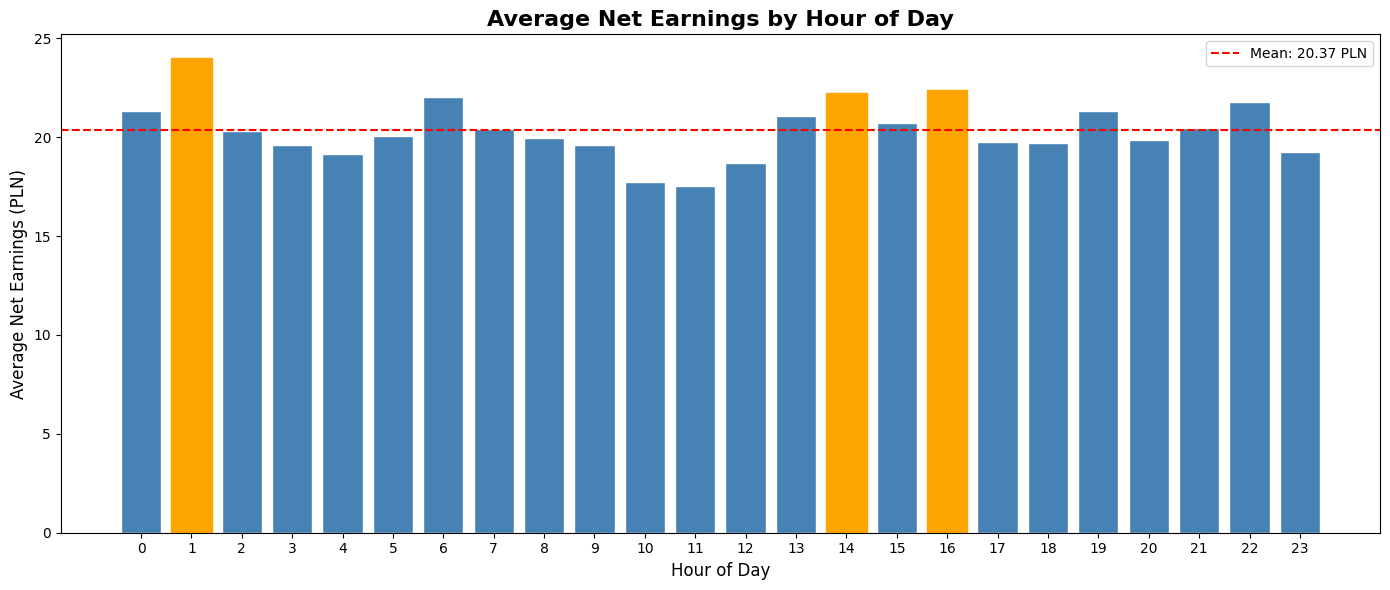

Top 5 Most Profitable Hours:
   hour  total_trips  avg_net_earnings_no_tips
0     1            8                 23.997500
1    16          348                 22.384224
2    14          205                 22.246878
3     6          117                 22.029829
4    22           19                 21.761053


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# which hour of the day is most profitable for Uber trips based on average net earnings (excluding tips)

# Sort by hour
hourly_revenue_gold = hourly_revenue_gold.sort_values('hour')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    hourly_revenue_gold['hour'],
    hourly_revenue_gold['avg_net_earnings_no_tips'],
    color='steelblue',
    edgecolor='white'
)

# Highlighting  top 3 hours
top_3 = hourly_revenue_gold.nlargest(3, 'avg_net_earnings_no_tips')['hour']
for bar, hour in zip(bars, hourly_revenue_gold['hour']):
    if hour in top_3.values:
        bar.set_color('orange')

# adding mean line to the plot to indicate the average net earnings across all hours for Uber trips.
mean_earnings = hourly_revenue_gold['avg_net_earnings_no_tips'].mean()
ax.axhline(y=mean_earnings, color='red', linestyle='--', 
           label=f'Mean: {mean_earnings:.2f} PLN')

# Labels
ax.set_title('Average Net Earnings by Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Net Earnings (PLN)', fontsize=12)
ax.set_xticks(range(24))
ax.legend()

plt.tight_layout()
plt.show()

# Printing the top 5 most profitable hours
print("Top 5 Most Profitable Hours:")
print(hourly_revenue_gold.nlargest(5, 'avg_net_earnings_no_tips')[
    ['hour', 'total_trips', 'avg_net_earnings_no_tips']
].reset_index(drop=True).to_string())

Business Question 2: Which day of the week is most profitable?

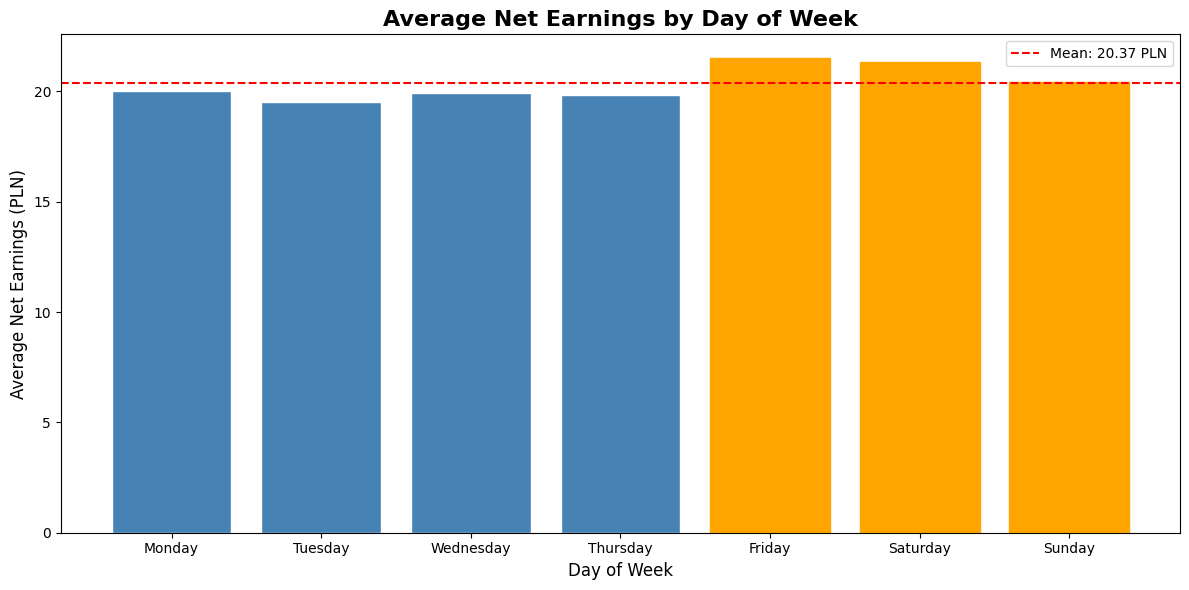

Days Ranked by Average Earnings:
    week_day  total_trips  avg_net_earnings_no_tips
0     Friday          486                 21.513395
1   Saturday          709                 21.350959
2     Sunday          282                 20.424291
3     Monday          334                 20.006527
4  Wednesday          303                 19.948317
5   Thursday          319                 19.859310
6    Tuesday          306                 19.512647


In [ ]:
# defining the order of days for plotting purposes to ensure that the days are displayed in the correct sequence on the plot.
day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# sorting by day order to ensure the days are displayed in the correct sequence on the plot.
day_of_week_revenue_gold['week_day'] = pd.Categorical(
    day_of_week_revenue_gold['week_day'], 
    categories=day_order, 
    ordered=True
)
day_of_week_revenue_gold = day_of_week_revenue_gold.sort_values('week_day')

# plot
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    day_of_week_revenue_gold['week_day'],
    day_of_week_revenue_gold['avg_net_earnings_no_tips'],
    color='steelblue',
    edgecolor='white'
)

# Highlighting the  top 3 days
top_3 = day_of_week_revenue_gold.nlargest(3, 'avg_net_earnings_no_tips')['week_day']
for bar, day in zip(bars, day_of_week_revenue_gold['week_day']):
    if day in top_3.values:
        bar.set_color('orange')

# adding mean line to the plot to indicate the average net earnings across all days of the week for Uber trips.
mean_earnings = day_of_week_revenue_gold['avg_net_earnings_no_tips'].mean()
ax.axhline(y=mean_earnings, color='red', linestyle='--',
           label=f'Mean: {mean_earnings:.2f} PLN')

# labels
ax.set_title('Average Net Earnings by Day of Week', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Net Earnings (PLN)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Print ranking
print("Days Ranked by Average Earnings:")
print(day_of_week_revenue_gold[['week_day', 'total_trips', 
                         'avg_net_earnings_no_tips']]
      .sort_values('avg_net_earnings_no_tips', ascending=False)
      .reset_index(drop=True).to_string())

Business Question 3: What is weekly  total earnings?

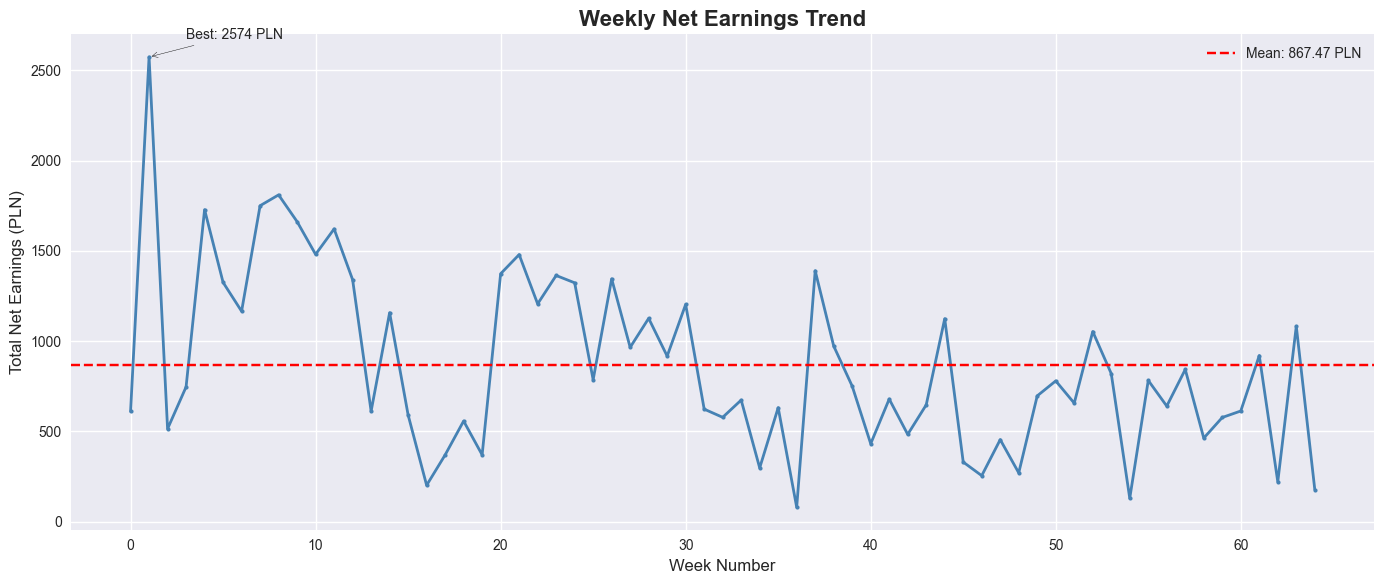

Weekly Earnings Summary:
Best Week:    2024-10-06 00:00:00 → 2573.58 PLN
Worst Week:   2025-06-22 00:00:00 → 79.80 PLN
Average Week: 867.47 PLN


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    range(len(weekly_revenue_gold)),
    weekly_revenue_gold['total_net_earnings_no_tips'],
    color='steelblue',
    linewidth=2,
    marker='o',
    markersize=3
)

# adding mean line to the plot to indicate the average net earnings across all weeks for Uber trips.
weekly_mean = weekly_revenue_gold['total_net_earnings_no_tips'].mean()
ax.axhline(y=weekly_mean, color='red', linestyle='--',
           label=f'Mean: {weekly_mean:.2f} PLN')

# annotatating the  best week
best_week_idx = weekly_revenue_gold['total_net_earnings_no_tips'].idxmax()
ax.annotate(
    f"Best: {weekly_revenue_gold.loc[best_week_idx, 'total_net_earnings_no_tips']:.0f} PLN",
    xy=(best_week_idx, weekly_revenue_gold.loc[best_week_idx, 'total_net_earnings_no_tips']),
    xytext=(best_week_idx + 2, weekly_revenue_gold.loc[best_week_idx, 'total_net_earnings_no_tips'] + 100),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)
#labels
ax.set_title('Weekly Net Earnings Trend', fontsize=16, fontweight='bold')
ax.set_xlabel('Week Number', fontsize=12)
ax.set_ylabel('Total Net Earnings (PLN)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print("Weekly Earnings Summary:")
print(f"Best Week:    {weekly_revenue_gold.loc[weekly_revenue_gold['total_net_earnings_no_tips'].idxmax(), 'week']} → {weekly_revenue_gold['total_net_earnings_no_tips'].max():.2f} PLN")
print(f"Worst Week:   {weekly_revenue_gold.loc[weekly_revenue_gold['total_net_earnings_no_tips'].idxmin(), 'week']} → {weekly_revenue_gold['total_net_earnings_no_tips'].min():.2f} PLN")
print(f"Average Week: {weekly_mean:.2f} PLN")

Business Question 4: Which month of the year is most profitable?

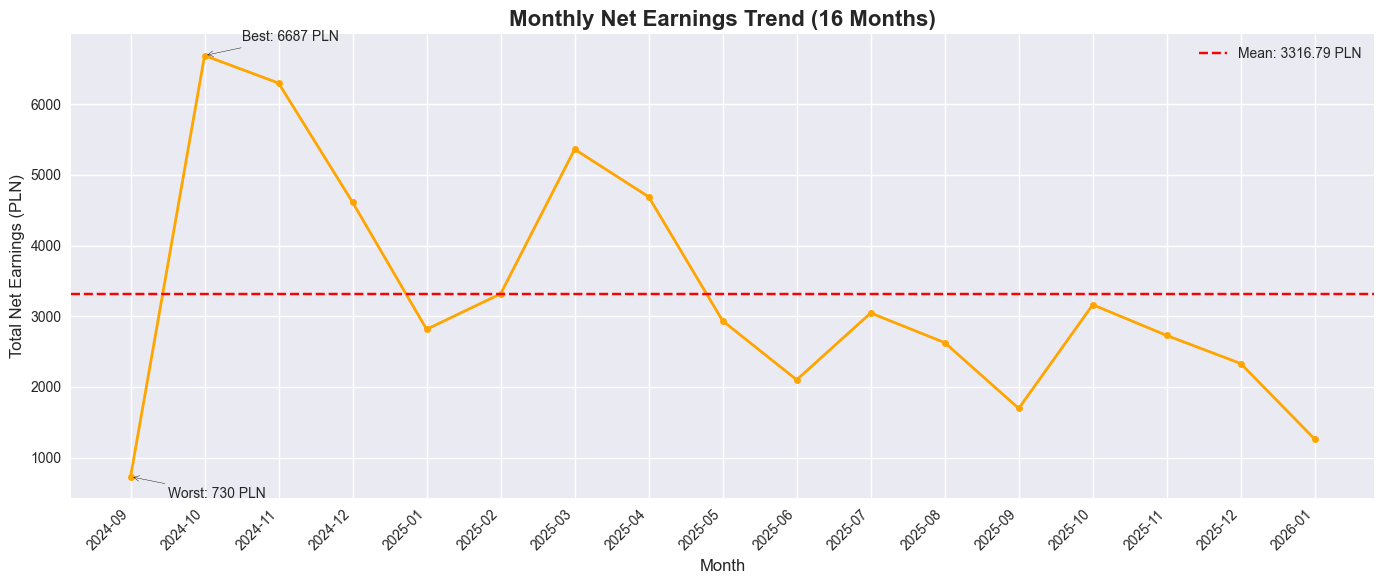

Monthly Earnings Summary:
Best Month:    2024-10 → 6687.10 PLN
Worst Month:   2024-09 → 729.68 PLN
Average Month: 3316.79 PLN

All Months Ranked:
   year_month  total_trips  total_net_earnings_no_tips
0     2024-10          337                     6687.10
1     2024-11          297                     6297.47
2     2025-03          271                     5361.18
3     2025-04          242                     4688.64
4     2024-12          217                     4610.39
5     2025-02          185                     3316.61
6     2025-10          140                     3162.23
7     2025-07          151                     3045.14
8     2025-05          138                     2933.55
9     2025-01          127                     2814.51
10    2025-11          127                     2727.19
11    2025-08          122                     2626.03
12    2025-12          102                     2329.94
13    2025-06          111                     2100.15
14    2025-09           72   

In [46]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    range(len(yearly_monthly_revenue_gold)),
    yearly_monthly_revenue_gold['total_net_earnings_no_tips'],
    color='orange',
    linewidth=2,
    marker='o',
    markersize=5
)

# Add mean line
monthly_mean = yearly_monthly_revenue_gold['total_net_earnings_no_tips'].mean()
ax.axhline(y=monthly_mean, color='red', linestyle='--',
           label=f'Mean: {monthly_mean:.2f} PLN')

# Add month labels
ax.set_xticks(range(len(yearly_monthly_revenue_gold)))
ax.set_xticklabels(
    yearly_monthly_revenue_gold['year_month'],
    rotation=45,
    ha='right'
)

# Annotate best month
best_month_idx = yearly_monthly_revenue_gold['total_net_earnings_no_tips'].idxmax()
ax.annotate(
    f"Best: {yearly_monthly_revenue_gold.loc[best_month_idx, 'total_net_earnings_no_tips']:.0f} PLN",
    xy=(best_month_idx, yearly_monthly_revenue_gold.loc[best_month_idx, 'total_net_earnings_no_tips']),
    xytext=(best_month_idx + 0.5, yearly_monthly_revenue_gold.loc[best_month_idx, 'total_net_earnings_no_tips'] + 200),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

# Annotate worst month
worst_month_idx = yearly_monthly_revenue_gold['total_net_earnings_no_tips'].idxmin()
ax.annotate(
    f"Worst: {yearly_monthly_revenue_gold.loc[worst_month_idx, 'total_net_earnings_no_tips']:.0f} PLN",
    xy=(worst_month_idx, yearly_monthly_revenue_gold.loc[worst_month_idx, 'total_net_earnings_no_tips']),
    xytext=(worst_month_idx + 0.5, yearly_monthly_revenue_gold.loc[worst_month_idx, 'total_net_earnings_no_tips'] - 300),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10
)

ax.set_title('Monthly Net Earnings Trend (16 Months)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Net Earnings (PLN)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print("Monthly Earnings Summary:")
print(f"Best Month:    {yearly_monthly_revenue_gold.loc[best_month_idx, 'year_month']} → {yearly_monthly_revenue_gold['total_net_earnings_no_tips'].max():.2f} PLN")
print(f"Worst Month:   {yearly_monthly_revenue_gold.loc[worst_month_idx, 'year_month']} → {yearly_monthly_revenue_gold['total_net_earnings_no_tips'].min():.2f} PLN")
print(f"Average Month: {monthly_mean:.2f} PLN")
print(f"\nAll Months Ranked:")
print(yearly_monthly_revenue_gold[['year_month', 'total_trips', 
                                    'total_net_earnings_no_tips']]
      .sort_values('total_net_earnings_no_tips', ascending=False)
      .reset_index(drop=True).to_string())

Business Question 5: Which month of the year is most profitable?

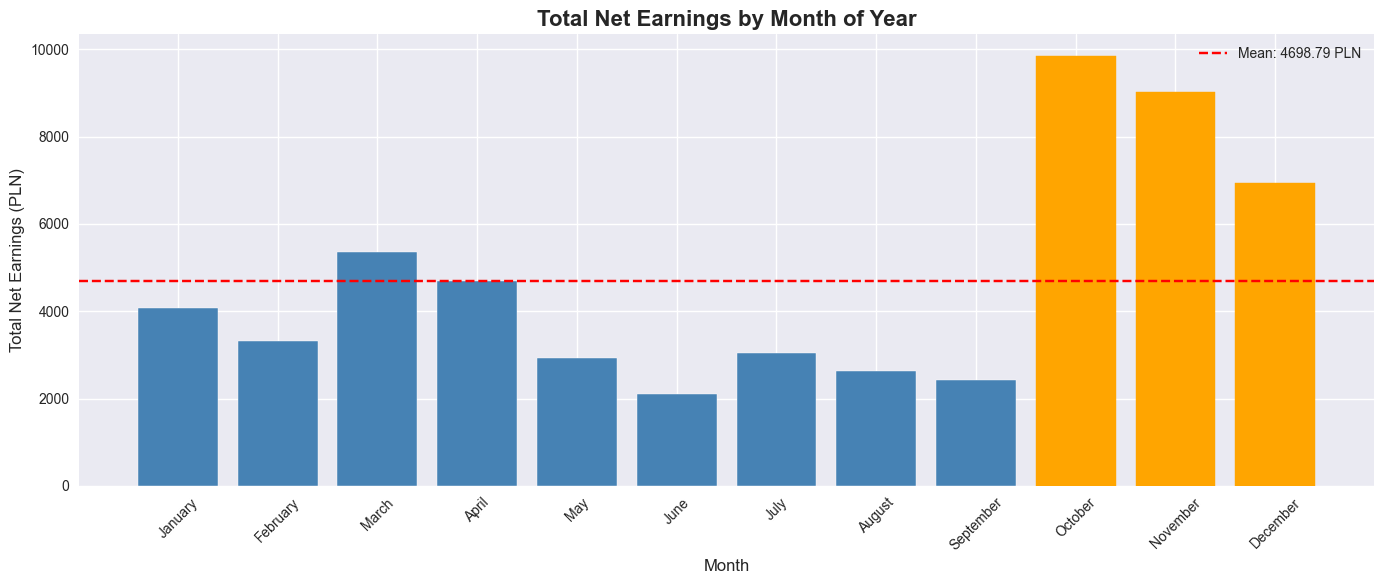

Months Ranked by Total Earnings:
   month_name  total_trips  total_net_earnings_no_tips
0     October          477                     9849.33
1    November          424                     9024.66
2    December          319                     6940.33
3       March          271                     5361.18
4       April          242                     4688.64
5     January          186                     4074.52
6    February          185                     3316.61
7        July          151                     3045.14
8         May          138                     2933.55
9      August          122                     2626.03
10  September          113                     2425.36
11       June          111                     2100.15


In [58]:
# Map month numbers to names
month_names = {
    1: 'January', 2: 'February', 3: 'March',
    4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September',
    10: 'October', 11: 'November', 12: 'December'
}

monthly_revenue_gold['month_name'] = monthly_revenue_gold['month'].map(month_names)

# Define correct order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_revenue_gold['month_name'] = pd.Categorical(
    monthly_revenue_gold['month_name'],
    categories=month_order,
    ordered=True
)

monthly_revenue_gold = monthly_revenue_gold.sort_values('month_name')

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    monthly_revenue_gold['month_name'],
    monthly_revenue_gold['total_net_earnings_no_tips'],
    color='steelblue',
    edgecolor='white'
)

# Highlight top 3 months
top_3 = monthly_revenue_gold.nlargest(3, 'total_net_earnings_no_tips')['month_name']
for bar, month in zip(bars, monthly_revenue_gold['month_name']):
    if month in top_3.values:
        bar.set_color('orange')

# Add mean line
monthly_mean = monthly_revenue_gold['total_net_earnings_no_tips'].mean()
ax.axhline(y=monthly_mean, color='red', linestyle='--',
           label=f'Mean: {monthly_mean:.2f} PLN')

ax.set_title('Total Net Earnings by Month of Year',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Net Earnings (PLN)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# Print ranking
print("Months Ranked by Total Earnings:")
print(monthly_revenue_gold[['month_name', 'total_trips',
                             'total_net_earnings_no_tips']]
      .sort_values('total_net_earnings_no_tips', ascending=False)
      .reset_index(drop=True).to_string())

In [28]:
# checking the shape,null values and duplicates of all gold tables to ensure data integrity and completeness.
gold_tables = {
    'daily_revenue' : daily_revenue_gold,
    'hourly_revenue' : hourly_revenue_gold,
    'day_of_week_revenue': day_of_week_revenue_gold,
    'weekly_revenue': weekly_revenue_gold,
    'monthly_revenue' : monthly_revenue_gold,
    'yearly_monthly_revenue': yearly_monthly_revenue_gold,
    'daily_demand' :daily_demand_gold,
    'hourly_demand' : hourly_demand_gold,
    'seasonal_demand' : seasonal_demand_gold

}
print(f"{'name':<25}{'shape':<25}{'null':<10}{'duplicates':<10}")
print('-'*70)
for name, df in gold_tables.items():
    nulls = df.isnull().sum().sum()
    duplicates = df.duplicated().sum()
    print(f"{(name):<25}{str(df.shape):<25}{nulls:<10}{duplicates:<10}")

name                     shape                    null      duplicates
----------------------------------------------------------------------
daily_revenue            (334, 13)                0         0         
hourly_revenue           (24, 13)                 0         0         
day_of_week_revenue      (7, 13)                  0         0         
weekly_revenue           (69, 13)                 16        0         
monthly_revenue          (12, 13)                 0         0         
yearly_monthly_revenue   (17, 13)                 0         0         
daily_demand             (7, 4)                   0         0         
hourly_demand            (24, 4)                  0         0         
seasonal_demand          (4, 4)                   0         0         


In [29]:
#dropping the weeks with no trips from the weekly revenue summary to ensure that only weeks with completed trips are considered for analysis.
weekly_revenue_gold = weekly_revenue_gold[weekly_revenue_gold['total_trips']>0].reset_index(drop=True)
print(weekly_revenue_gold.isnull().sum().sum())

0


In [30]:
weekly_revenue_gold.shape

(65, 13)

In [31]:
#checking the data types of all gold tables to ensure consistency and correctness of data types for further analysis.
for name, df in gold_tables.items():
    print(f"---{name} dtypes---")
    print(df.dtypes)
    print("\n")

---daily_revenue dtypes---
date                             object
total_trips                       int64
total_revenue                   float64
total_net_earnings_no_tips      float64
total_tips                      float64
total_net_earnings_with_tips    float64
avg_net_earnings_no_tips        float64
distance_covered                float64
avg_distance_per_trip           float64
total_duration                  float64
uber_deduction                  float64
uber_deduction_%                float64
earnings_per_km                 float64
dtype: object


---hourly_revenue dtypes---
hour                              int32
total_trips                       int64
total_revenue                   float64
total_net_earnings_no_tips      float64
total_tips                      float64
total_net_earnings_with_tips    float64
avg_net_earnings_no_tips        float64
distance_covered                float64
avg_distance_per_trip           float64
total_duration                  float64
uber_dedu

In [32]:
#checking the head (3) and tail (3) records of all gold tables to ensure data integrity and completeness.
for name, df in gold_tables.items():
    print(f"---head(3) and tail(3) of {name}---")
    print("\nHead 3:")
    print(df.head(3))
    print("\nTail 3:")
    print(df.tail(3))
    print("\n")

---head(3) and tail(3) of daily_revenue---

Head 3:
         date  total_trips  total_revenue  total_net_earnings_no_tips  \
0  2024-09-23            5          86.25                       65.11   
1  2024-09-25            8         236.69                      167.34   
2  2024-09-26           17         531.98                      377.66   

   total_tips  total_net_earnings_with_tips  avg_net_earnings_no_tips  \
0         0.0                         65.11                 13.022000   
1         0.0                        167.34                 20.917500   
2         0.0                        377.66                 22.215294   

   distance_covered  avg_distance_per_trip  total_duration  uber_deduction  \
0          27734.91            5546.982000          3043.0           21.14   
1          56786.87            7098.358750          8825.0           69.35   
2         130961.27            7703.604118         18740.0          154.32   

   uber_deduction_%  earnings_per_km  
0         

           date  total_trips  total_revenue  total_net_earnings_no_tips  \
331  2026-01-10           20         602.18                      414.35   
332  2026-01-11            5         164.71                      124.50   
333  2026-01-12            7         244.67                      177.86   

     total_tips  total_net_earnings_with_tips  avg_net_earnings_no_tips  \
331         2.0                        416.35                 20.717500   
332         0.0                        124.50                 24.900000   
333         0.0                        177.86                 25.408571   

     distance_covered  avg_distance_per_trip  total_duration  uber_deduction  \
331         154763.78            7738.189000         22453.0          187.83   
332          36252.83            7250.566000          5847.0           40.21   
333          44959.57            6422.795714          7635.0           66.81   

     uber_deduction_%  earnings_per_km  
331         31.191670             2.

In [33]:
#changing the data type of the date column in the daily revenue summary to datetime format for further analysis.
daily_revenue_gold['date']= pd.to_datetime(daily_revenue_gold['date'])
print(daily_revenue_gold.dtypes['date'])

datetime64[s]


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette('Blues_d')

# Set figure size default
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [35]:
daily_revenue_gold.describe().T

,count,mean,min,25%,50%,75%,max,std
date,334,2025-05-07 09:03:14,2024-09-23 00:00:00,2025-01-12 06:00:00,2025-04-25 12:00:00,2025-08-23 18:00:00,2026-01-12 00:00:00,NaN
total_trips,334.0,8.200599,1.0,4.0,7.0,11.0,28.0,5.532204
total_revenue,334.0,237.468383,18.93,119.2275,197.095,317.96,822.82,162.478537
total_net_earnings_no_tips,334.0,168.818862,11.64,79.97,141.96,225.11,554.2,115.934545
total_tips,334.0,2.264222,0.0,0.0,0.0,2.0,40.0,4.689053
total_net_earnings_with_tips,334.0,171.083084,11.64,83.2975,143.685,227.86,557.33,117.173762
avg_net_earnings_no_tips,334.0,20.76212,10.654,17.9395,20.344275,23.0075,39.335,4.308405
distance_covered,334.0,56803.027964,3079.94,27019.215,45399.005,75910.9475,206653.02,41067.236557
avg_distance_per_trip,334.0,6928.592442,2094.59,5696.205227,6863.014758,7903.326357,13827.48,1885.652065
total_duration,334.0,8476.182635,504.0,4471.25,7304.5,11812.0,27032.0,5549.650941


In [36]:
daily_revenue_gold.head()

,date,total_trips,total_revenue,total_net_earnings_no_tips,total_tips,total_net_earnings_with_tips,avg_net_earnings_no_tips,distance_covered,avg_distance_per_trip,total_duration,uber_deduction,uber_deduction_%,earnings_per_km
0,2024-09-23,5,86.25,65.11,0.0,65.11,13.022000,27734.91,5546.982000,3043.0,21.14,24.510145,2.35
1,2024-09-25,8,236.69,167.34,0.0,167.34,20.917500,56786.87,7098.358750,8825.0,69.35,29.299928,2.95
2,2024-09-26,17,531.98,377.66,0.0,377.66,22.215294,130961.27,7703.604118,18740.0,154.32,29.008609,2.88
3,2024-09-30,11,186.86,119.57,2.0,121.57,10.870000,38539.24,3503.567273,5902.0,67.29,36.010917,3.10
4,2024-10-01,12,300.50,215.16,0.0,215.16,17.930000,75676.21,6306.350833,11849.0,85.34,28.399334,2.84


In [37]:
daily_revenue_gold.columns.to_list()

['date',
 'total_trips',
 'total_revenue',
 'total_net_earnings_no_tips',
 'total_tips',
 'total_net_earnings_with_tips',
 'avg_net_earnings_no_tips',
 'distance_covered',
 'avg_distance_per_trip',
 'total_duration',
 'uber_deduction',
 'uber_deduction_%',
 'earnings_per_km']

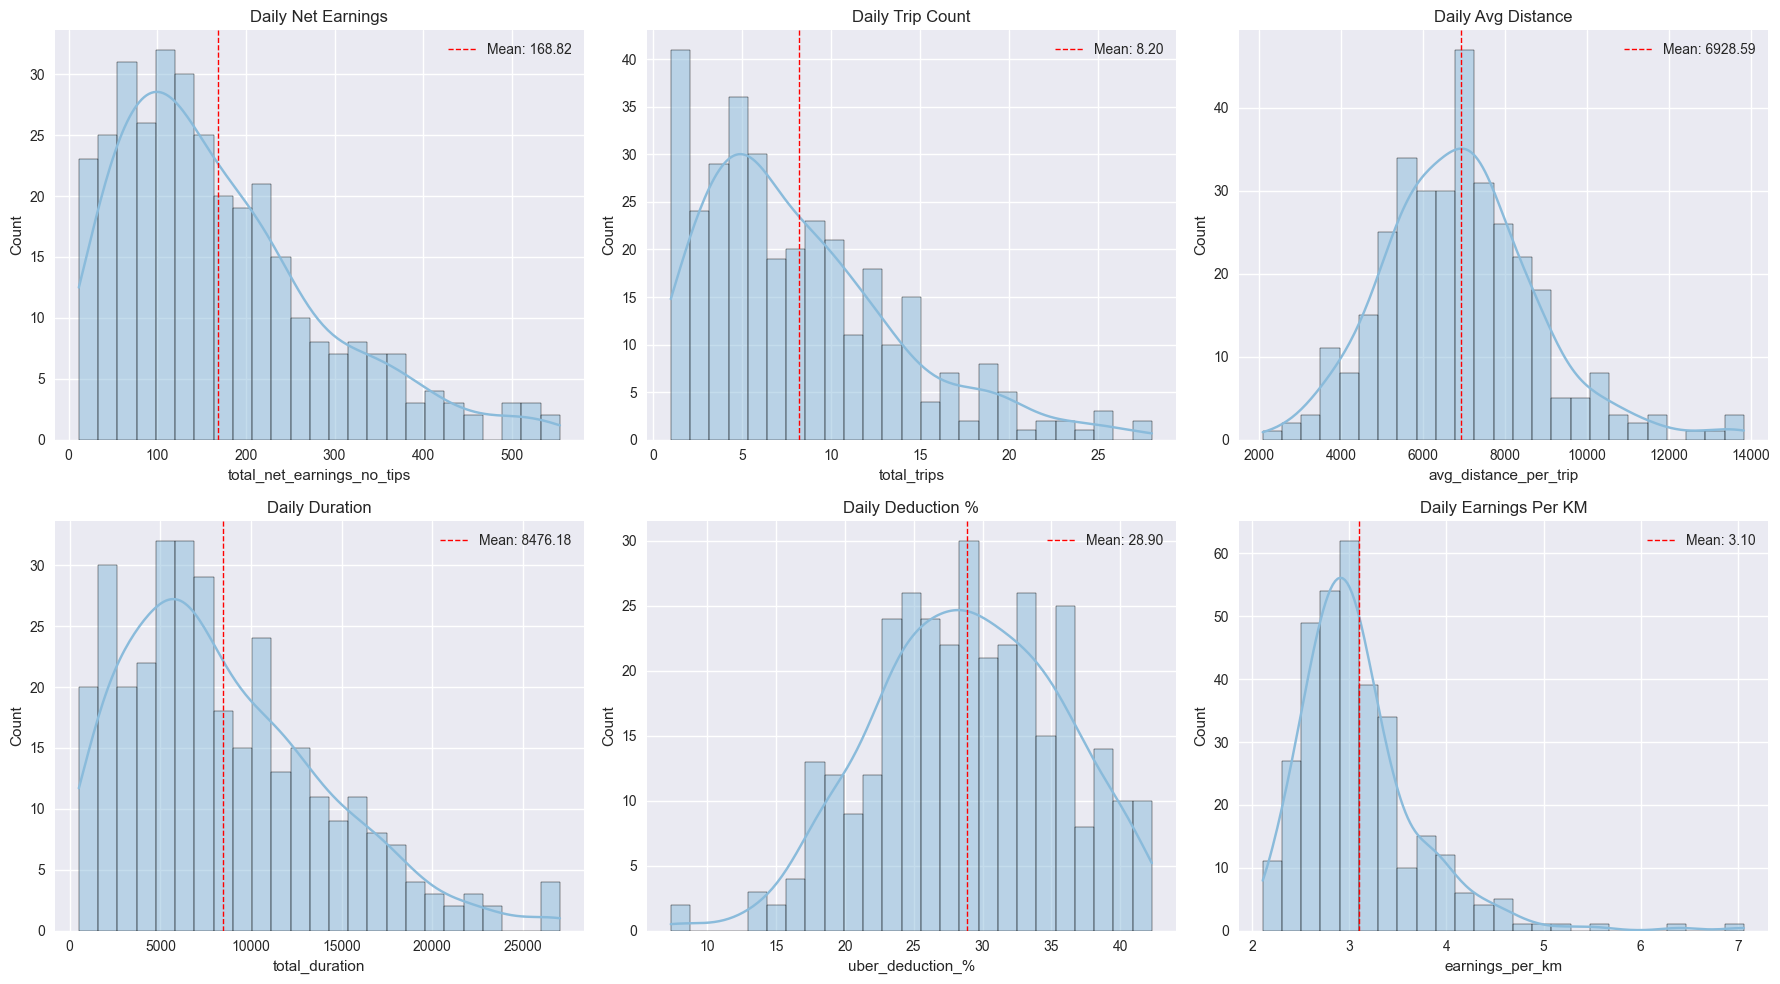

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot_daily ={
    'Daily Net Earnings': daily_revenue_gold['total_net_earnings_no_tips'],
    'Daily Trip Count': daily_revenue_gold['total_trips'],
    'Daily Avg Distance': daily_revenue_gold['avg_distance_per_trip'],
    'Daily Duration': daily_revenue_gold['total_duration'],
    'Daily Deduction %': daily_revenue_gold['uber_deduction_%'],
    'Daily Earnings Per KM': daily_revenue_gold['earnings_per_km']
    
}
fig,ax = plt.subplots(2,3,figsize=(18,10))
axes = ax.flatten()
for i, (title,data) in enumerate(cols_to_plot_daily.items()):
    sns.histplot(data, bins=25, kde=True, ax=axes[i])
    axes[i].set_title(title)
    axes[i].axvline(data.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {data.mean():.2f}')
    axes[i].legend()
plt.tight_layout()
plt.show()


In [39]:
daily_revenue_gold
weekly_revenue_gold
hourly_revenue_gold
monthly_revenue_gold
yearly_monthly_revenue_gold
daily_demand_gold
hourly_demand_gold
seasonal_demand_gold

,season,total_trips,avg_distance,avg_duration
0,Autumn,1600,6707.945806,1020.928750
1,Spring,856,6676.806893,975.552570
2,Summer,886,6623.952698,957.566591
3,Winter,993,6622.565217,996.633434


In [40]:
daily_demand_gold.head()

,day_of_week,total_trips,avg_distance,avg_duration
0,Friday,814,6772.706843,1045.760442
1,Monday,501,6303.187685,1030.329341
2,Saturday,1146,6998.733613,922.629145
3,Sunday,464,6986.300302,850.519397
4,Thursday,481,6434.201185,1045.590437


In [41]:
weekly_revenue_gold.columns.to_list()

['week',
 'total_trips',
 'total_revenue',
 'total_net_earnings_no_tips',
 'total_tips',
 'total_net_earnings_with_tips',
 'avg_net_earnings_no_tips',
 'distance_covered',
 'avg_distance_per_trip',
 'total_duration',
 'uber_deduction',
 'uber_deduction_%',
 'earnings_per_km']